# NutriVision AI

## Data Preprocessing

### Objective

This notebook prepares the Food-101 dataset for deep learning.

Tasks:

- Select required food classes
- Resize images
- Split dataset
- Save processed dataset
- Verify dataset integrity

In [10]:
#Import Libraries
import os
import random
import shutil
from pathlib import Path

import pandas as pd

from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split

In [11]:
#Configuration
PROJECT_PATH = Path(r"D:\projects\NutriVision-AI")

RAW_DATASET = PROJECT_PATH / "data" / "raw" / "food-101" / "images"

PROCESSED_DATASET = PROJECT_PATH / "data" / "processed" / "food30"

IMAGE_SIZE = (224, 224)

RANDOM_STATE = 42

random.seed(RANDOM_STATE)

In [12]:
print(RAW_DATASET)
print(RAW_DATASET.exists())

D:\projects\NutriVision-AI\data\raw\food-101\images
True


In [13]:
#Selected Classes
SELECTED_CLASSES = [

    "apple_pie",
    "beef_carpaccio",
    "caesar_salad",
    "cheesecake",
    "chicken_curry",
    "chicken_wings",
    "club_sandwich",
    "dumplings",
    "fish_and_chips",
    "french_fries",
    "fried_calamari",
    "fried_rice",
    "grilled_cheese_sandwich",
    "grilled_salmon",
    "hamburger",
    "hot_dog",
    "ice_cream",
    "lasagna",
    "macaroni_and_cheese",
    "omelette",
    "pho",
    "pizza",
    "ramen",
    "samosa",
    "spaghetti_bolognese",
    "steak",
    "strawberry_shortcake",
    "sushi",
    "waffles",
    "chocolate_cake"

]

In [14]:
#Create Folder Structure
splits = ["train", "validation", "test"]

for split in splits:

    for cls in SELECTED_CLASSES:

        (PROCESSED_DATASET / split / cls).mkdir(
            parents=True,
            exist_ok=True
        )

print("Folder structure created.")

Folder structure created.


In [15]:
#Function to Resize and Save
def resize_and_save(source_path, destination_path):

    image = Image.open(source_path)

    image = image.convert("RGB")

    image = image.resize(IMAGE_SIZE)

    image.save(destination_path)

In [16]:
#Copy + Split Dataset
summary = []

for cls in tqdm(SELECTED_CLASSES):

    image_paths = list((RAW_DATASET / cls).glob("*.jpg"))

    train_imgs, temp_imgs = train_test_split(
        image_paths,
        test_size=0.30,
        random_state=RANDOM_STATE
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=RANDOM_STATE
    )

    datasets = {

        "train": train_imgs,
        "validation": val_imgs,
        "test": test_imgs

    }

    for split, files in datasets.items():

        for img_path in files:

            destination = (
                PROCESSED_DATASET /
                split /
                cls /
                img_path.name
            )

            resize_and_save(img_path, destination)

    summary.append({

        "Class": cls,
        "Train": len(train_imgs),
        "Validation": len(val_imgs),
        "Test": len(test_imgs)

    })

100%|██████████| 30/30 [07:30<00:00, 15.01s/it]


In [17]:
#Summary Table
summary_df = pd.DataFrame(summary)

summary_df

,Class,Train,Validation,Test
0,apple_pie,700,150,150
1,beef_carpaccio,700,150,150
2,caesar_salad,700,150,150
3,cheesecake,700,150,150
4,chicken_curry,700,150,150
5,chicken_wings,700,150,150
6,club_sandwich,700,150,150
7,dumplings,700,150,150
8,fish_and_chips,700,150,150
9,french_fries,700,150,150


In [18]:
#Save Summary
OUTPUT = PROJECT_PATH / "outputs" / "metrics"

OUTPUT.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(

    OUTPUT / "dataset_split_summary.csv",

    index=False

)

In [19]:
#Verify Dataset
train_total = 0
val_total = 0
test_total = 0

for cls in SELECTED_CLASSES:

    train_total += len(
        list((PROCESSED_DATASET/"train"/cls).glob("*.jpg"))
    )

    val_total += len(
        list((PROCESSED_DATASET/"validation"/cls).glob("*.jpg"))
    )

    test_total += len(
        list((PROCESSED_DATASET/"test"/cls).glob("*.jpg"))
    )

print("Training Images :", train_total)
print("Validation Images :", val_total)
print("Testing Images :", test_total)

Training Images : 21000
Validation Images : 4500
Testing Images : 4500


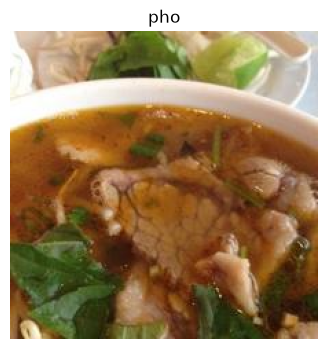

In [20]:
#Visual Verification
import matplotlib.pyplot as plt

sample_class = random.choice(SELECTED_CLASSES)

sample_image = random.choice(
    list((PROCESSED_DATASET/"train"/sample_class).glob("*.jpg"))
)

image = Image.open(sample_image)

plt.figure(figsize=(4,4))

plt.imshow(image)

plt.title(sample_class)

plt.axis("off")

plt.show()

In [21]:
#Check Image Size
print(image.size)

(224, 224)


# Summary

Completed preprocessing successfully.

✔ Selected 30 food categories

✔ Resized all images to 224 × 224

✔ Split dataset into

- Train : 70%

- Validation : 15%

- Test : 15%

✔ Saved processed dataset

The dataset is now ready for transfer learning using MobileNetV2, ResNet50 and EfficientNetB0.